# Types of Distribution Explained with Real-Life Examples

## 📌 Objectives
This report dives into key probability distributions like normal, binomial, Poisson, exponential, and uniform to strengthen stats basics for data analysis and modeling.

**Main goals:**
- explain properties of discrete (binomial, Poisson) and continuous (normal, exponential, uniform) types
- show them with Python plots
- link to real examples

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm, binom, poisson, expon, uniform

## ☝️ Basics of Probability Distributions

### ℹ️ Defenition

A probability distribution describes how the values of a random variable are spread out and how likely each value is. In simple terms, it tells you **what outcomes are possible and how probable each outcome is.**

More formally, a probability distribution assigns probabilities to all possible values of a random variable in such a way that:

- Each probability is between 0 and 1
- The total probability over all possible outcomes equals 1

Probability distributions are a fundamental concept in statistics because they allow you to:

- Model uncertainty in real-world situations
- Summarize data in a meaningful way
- Make predictions and decisions based on likelihoods

They can be represented in several ways:

- A probability function (mathematical formula)
- A table of values and probabilities
- A graph (such as a bar chart or curve)

In addition, distributions are often described using key numerical summaries such as:

- Mean (expected value): the average outcome
- Variance and standard deviation: how spread out the values are

### ✌️ Discrete vs Continuous Distributions

There are two main types of probability distributions: **discrete** and **continuous**. The difference lies in the type of values the random variable can take.

**Discrete Distributions**

A discrete distribution applies to random variables that take countable values (usually integers).

- The number of possible outcomes is finite or countably infinite
- Each specific value has a non-zero probability
- Described by a probability mass function (PMF)

**Examples:**

- Number of heads in 10 coin flips
- Number of customers arriving in a store
- Number of defective items in a batch

**Common discrete distributions include:**

- Binomial distribution (fixed number of trials)
- Poisson distribution (counts of events over time/space)

---

**Continuous Distributions**

A continuous distribution applies to random variables that can take any value within an interval.

- There are infinitely many possible values
- The probability of any exact value is zero
- Probabilities are assigned over intervals
- Described by a probability density function (PDF)

**Examples:**

- Height or weight of a person
- Time taken to complete a task
- Temperature measurements

**Common continuous distributions include:**

- Normal distribution (bell-shaped curve)
- Exponential distribution (time between events)
- Uniform distribution (all values equally likely in a range)

---
**Key Intuition**
- Discrete = counting → exact probabilities
- Continuous = measuring → probabilities over ranges

**For example:**

- Discrete: “What is the probability of exactly 3 customers arriving?”
- Continuous: “What is the probability the waiting time is between 2 and 5 minutes?”

### 🌠 Visualization

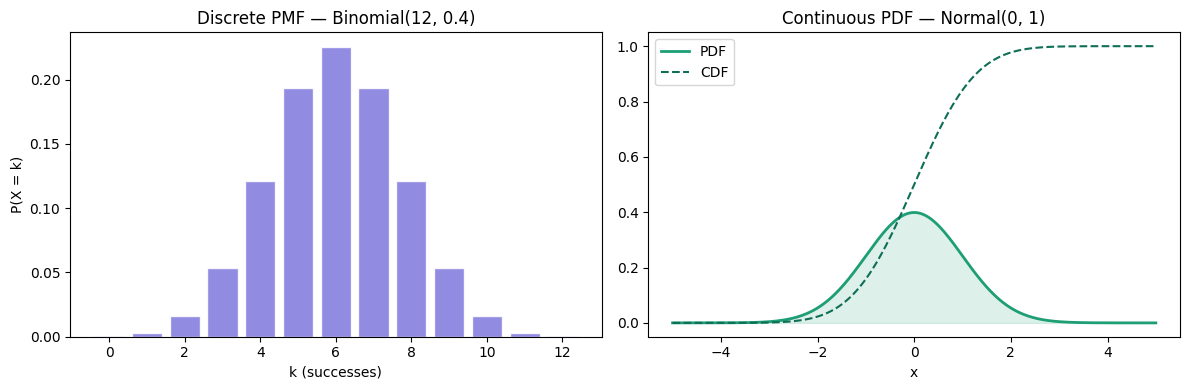

In [2]:
# ── Discrete: Binomial distribution ───────────────────────────
n, p = 12, 0.5
k    = np.arange(0, n + 1)
pmf  = stats.binom.pmf(k, n, p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(k, pmf, color='#7F77DD', alpha=0.85, edgecolor='white')
ax1.set_title('Discrete PMF — Binomial(12, 0.4)')
ax1.set_xlabel('k (successes)')
ax1.set_ylabel('P(X = k)')

# ── Continuous: Normal distribution ───────────────────────────
x    = np.linspace(-5, 5, 300)
pdf  = stats.norm.pdf(x, loc=0, scale=1)
cdf  = stats.norm.cdf(x, loc=0, scale=1)

ax2.plot(x, pdf, color='#1D9E75', linewidth=2, label='PDF')
ax2.fill_between(x, pdf, alpha=0.15, color='#1D9E75')
ax2.plot(x, cdf, color='#0F6E56', linewidth=1.5, linestyle='--', label='CDF')
ax2.set_title('Continuous PDF — Normal(0, 1)')
ax2.set_xlabel('x')
ax2.legend()

plt.tight_layout()
plt.show()

## 🌊 Normal Distribution

### ℹ️ Definition

The Normal Distribution (also called the Gaussian distribution) is a continuous probability distribution that is symmetric about its mean. It describes how values of a variable are distributed, and is the most important distribution in statistics due to the Central Limit Theorem which states that the sum of many independent random variables tends toward a normal distribution, regardless of their individual distributions.

**Probability Density Function (PDF)**

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

where:
- $x \in (-\infty, +\infty)$ — any real value
- $\mu$ — mean (location of the peak)
- $\sigma$ — standard deviation ($\sigma > 0$)
- $\sigma^2$ — variance

### 🛠️ Key properties

- Mean = Median = Mode — all three coincide at the center
- Symmetry — perfectly bell-shaped around the mean μ
- 68-95-99.7 rule — ~68% of data falls within 1σ, ~95% within 2σ, ~99.7% within 3σ
- Asymptotic tails — the curve never touches the x-axis
- Total area = 1 — it's a valid probability distribution
- Defined by just two parameters: mean μ (location) and standard deviation σ (spread)

### 🌠 Visualization

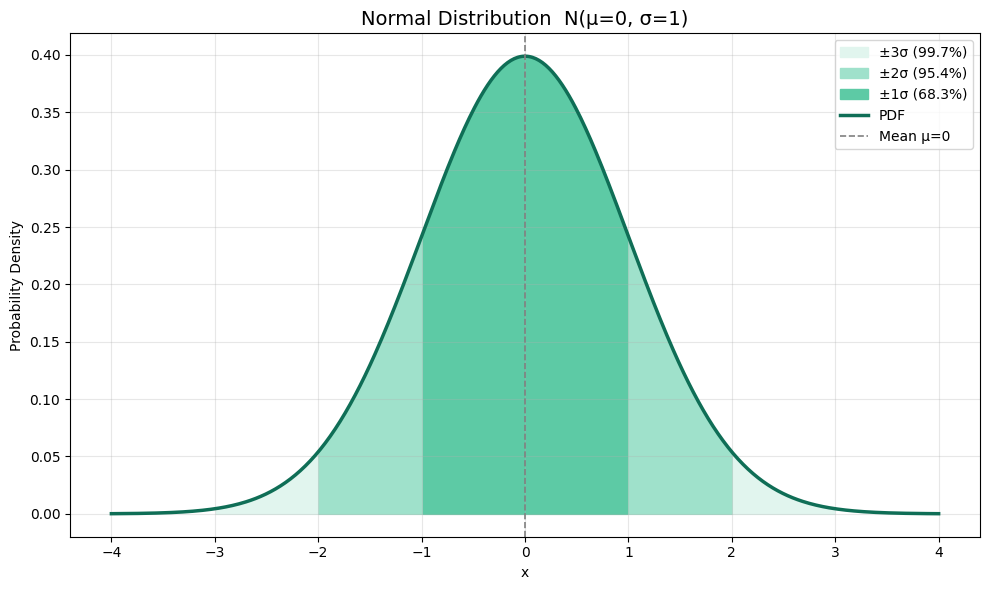

In [3]:
# Parameters
mu, sigma = 0, 1
x = np.linspace(-4, 4, 500)
pdf = norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(10, 6))

# Shade ±1σ, ±2σ, ±3σ regions
for n_std, color, label in [(3, '#E1F5EE', '±3σ (99.7%)'),
                             (2, '#9FE1CB', '±2σ (95.4%)'),
                             (1, '#5DCAA5', '±1σ (68.3%)')]:
    mask = (x >= mu - n_std * sigma) & (x <= mu + n_std * sigma)
    ax.fill_between(x, pdf, where=mask, color=color, label=label)

# PDF curve
ax.plot(x, pdf, color='#0F6E56', linewidth=2.5, label='PDF')

# Mean line
ax.axvline(mu, color='gray', linestyle='--', linewidth=1.2, label=f'Mean μ={mu}')

ax.set_title(f'Normal Distribution  N(μ={mu}, σ={sigma})', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('Probability Density')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 🚹 Real-Life Example: Student Exam Scores

Mean score   : 70.19
Std deviation: 9.79
Min / Max    : 37.59 / 108.53
Within ±1σ  : 69.8%  (theoretical: 68.3%)
Within ±2σ  : 95.9%  (theoretical: 95.4%)
Within ±3σ  : 99.7%  (theoretical: 99.7%)

P(score > 85)      : 0.0668  (6.7%)
P(60 < score < 80) : 0.6827  (68.3%)


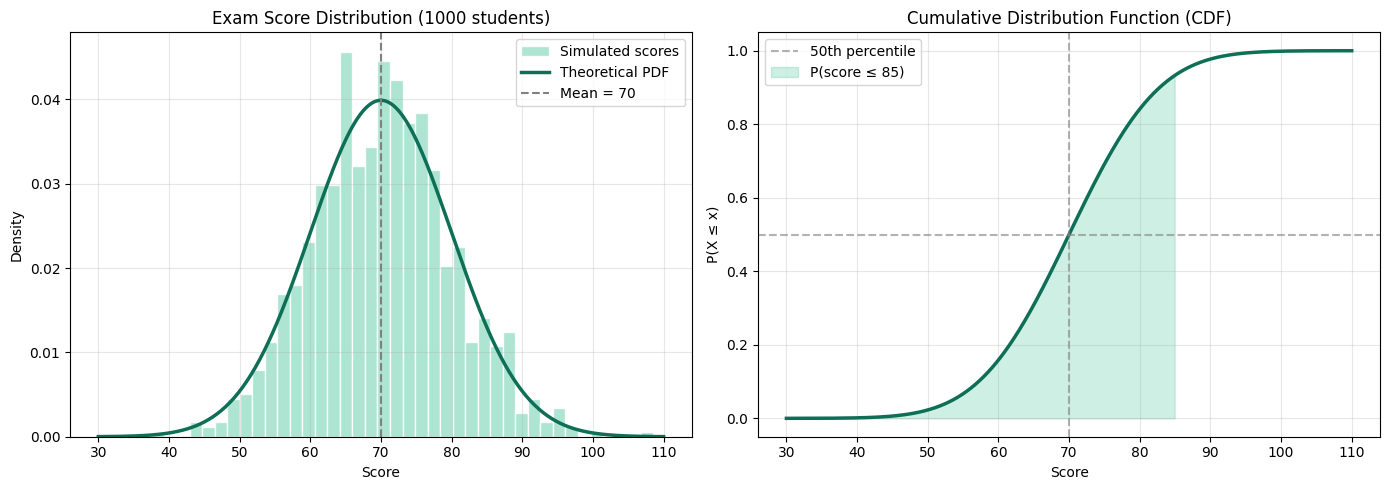

In [4]:
# Simulate exam scores for 1000 students
np.random.seed(42)
mu, sigma = 70, 10          # mean score = 70, std dev = 10
scores = np.random.normal(mu, sigma, 1000)

# ── Analysis ─────────────────────────────────────────────
print(f"Mean score   : {scores.mean():.2f}")
print(f"Std deviation: {scores.std():.2f}")
print(f"Min / Max    : {scores.min():.2f} / {scores.max():.2f}")

# Percentage of students within each σ band
for n in [1, 2, 3]:
    pct = np.mean((scores >= mu - n*sigma) & (scores <= mu + n*sigma)) * 100
    print(f"Within ±{n}σ  : {pct:.1f}%  (theoretical: {norm.cdf(n)-norm.cdf(-n):.1%})")

# ── Probability queries ───────────────────────────────────
p_above_85 = 1 - norm.cdf(85, mu, sigma)
p_between  = norm.cdf(80, mu, sigma) - norm.cdf(60, mu, sigma)

print(f"\nP(score > 85)      : {p_above_85:.4f}  ({p_above_85*100:.1f}%)")
print(f"P(60 < score < 80) : {p_between:.4f}  ({p_between*100:.1f}%)")

# ── Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of simulated scores
axes[0].hist(scores, bins=40, density=True,
             color='#9FE1CB', edgecolor='white', alpha=0.85, label='Simulated scores')
x = np.linspace(30, 110, 400)
axes[0].plot(x, norm.pdf(x, mu, sigma), color='#0F6E56', lw=2.5, label='Theoretical PDF')
axes[0].axvline(mu, color='gray', linestyle='--', label=f'Mean = {mu}')
axes[0].set_title('Exam Score Distribution (1000 students)')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Density')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: CDF — probability of scoring ≤ x
cdf = norm.cdf(x, mu, sigma)
axes[1].plot(x, cdf, color='#0F6E56', lw=2.5)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='50th percentile')
axes[1].axvline(mu, color='gray', linestyle='--', alpha=0.6)
axes[1].fill_between(x, cdf, where=(x <= 85),
                     color='#5DCAA5', alpha=0.3, label='P(score ≤ 85)')
axes[1].set_title('Cumulative Distribution Function (CDF)')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('P(X ≤ x)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 Binomial Distribution

### ℹ️ Definition

The Binomial Distribution is a discrete probability distribution that models the number of successes in a fixed number of independent trials, where each trial has exactly two possible outcomes: success or failure.

**Probability Mass Function (PMF)**

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

where the binomial coefficient is:

$$\binom{n}{k} = \frac{n!}{k!\,(n-k)!}$$

and:
- $k \in \{0, 1, 2, \ldots, n\}$ — number of successes
- $n$ — number of trials
- $p$ — probability of success on each trial
- $(1-p) = q$ — probability of failure


### 🛠️ Key properties

- Parameters: n = number of trials, p = probability of success per trial
- Discrete — X can only take integer values 0, 1, 2, ..., n
- Mean: μ = n · p
- Variance: σ² = n · p · (1−p)
- Standard deviation: σ = √(n · p · (1−p))
- Symmetry: the distribution is symmetric when p = 0.5, right-skewed when p < 0.5, left-skewed when p > 0.5
- Approaches Normal as n → ∞ (by the Central Limit Theorem)
- Each trial must be independent and have the same probability p (i.i.d. Bernoulli trials)

### 🌠 Visualization

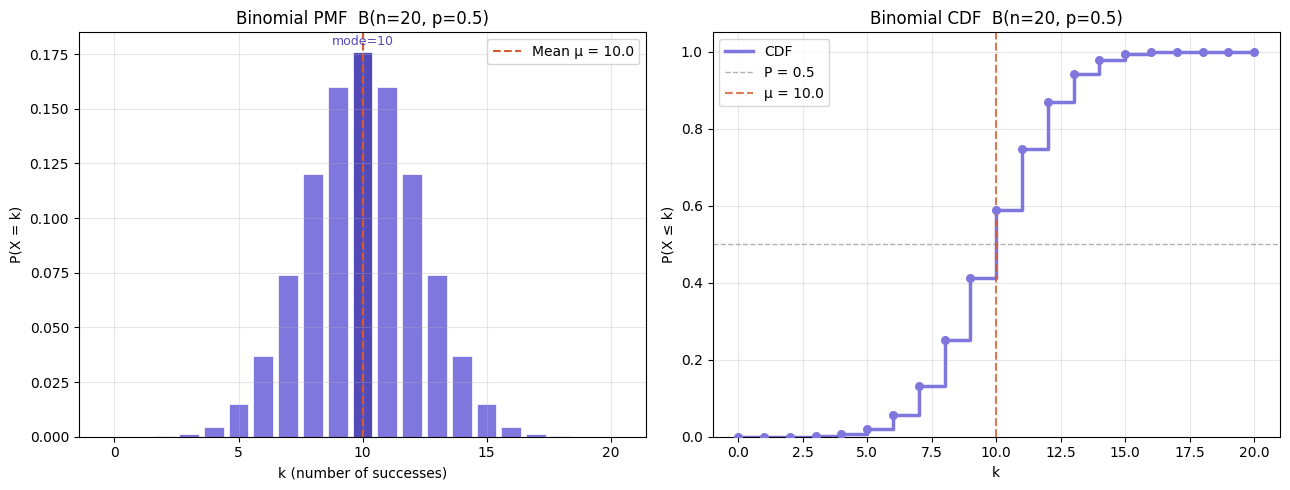

Mean     : 10.0000
Variance : 5.0000
Std Dev  : 2.2361


In [5]:
# Parameters
n, p = 20, 0.5
k = np.arange(0, n + 1)

# PMF and CDF
pmf = binom.pmf(k, n, p)
cdf = binom.cdf(k, n, p)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: PMF bar chart ───────────────────────────────────
mu = n * p
colors = ['#534AB7' if abs(ki - mu) < 0.5 else '#7F77DD' for ki in k]
axes[0].bar(k, pmf, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axvline(mu, color='#D85A30', linestyle='--', linewidth=1.5, label=f'Mean μ = {mu}')
axes[0].set_title(f'Binomial PMF  B(n={n}, p={p})')
axes[0].set_xlabel('k (number of successes)')
axes[0].set_ylabel('P(X = k)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Annotate mode bar
mode = int((n + 1) * p)
axes[0].text(mode, pmf[mode] + 0.003, f'mode={mode}',
             ha='center', fontsize=9, color='#534AB7')

# ── Right: CDF step chart ─────────────────────────────────
axes[1].step(k, cdf, where='post', color='#7F77DD', linewidth=2.5, label='CDF')
axes[1].scatter(k, cdf, color='#7F77DD', s=30, zorder=5)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='P = 0.5')
axes[1].axvline(mu, color='#D85A30', linestyle='--', linewidth=1.5, alpha=0.8, label=f'μ = {mu}')
axes[1].set_title(f'Binomial CDF  B(n={n}, p={p})')
axes[1].set_xlabel('k')
axes[1].set_ylabel('P(X ≤ k)')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Key statistics
print(f"Mean     : {binom.mean(n, p):.4f}")
print(f"Variance : {binom.var(n, p):.4f}")
print(f"Std Dev  : {binom.std(n, p):.4f}")

### 🚹 Real-Life Example — Quality Control in Manufacturing

A factory produces light bulbs. Each bulb has a 5% chance of being defective (p = 0.05). A quality inspector randomly picks 100 bulbs (n = 100). We want to understand how many defective bulbs to expect.

=== Quality Control Analysis ===
n = 100 bulbs,  p = 0.05 defect rate
Expected defects (mean)  : 5.00
Std deviation            : 2.18

P(0 defects)             : 0.0059  (0.6%)
P(≤2 defects)            : 0.1183  (11.8%)
P(1–7 defects)           : 0.8661  (86.6%)
P(≥10 defects) — alert!  : 0.0282  (2.82%)

Alert threshold          : ≥10 defects → reject batch
Batches falsely rejected : 2.82% (false alarm rate)

Simulation (10,000 batches):
Rejected batches         : 249 (2.49%)
Mean defects per batch   : 4.956


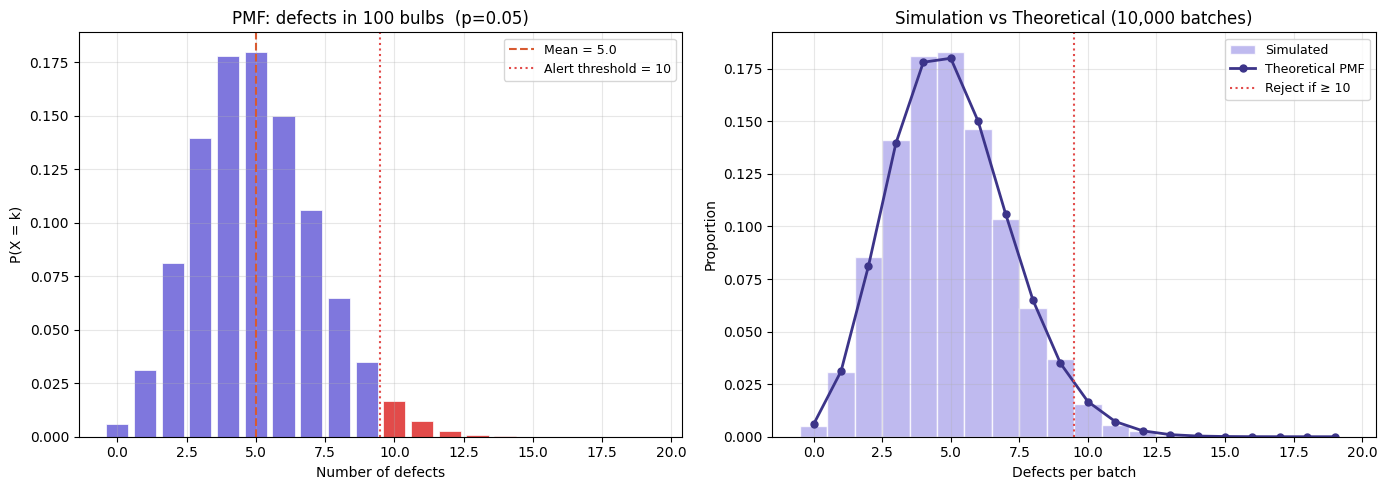

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# ── Setup ─────────────────────────────────────────────────
n = 100      # bulbs inspected per batch  ← changed
p = 0.05     # defect probability per bulb
k = np.arange(0, n + 1)
pmf = binom.pmf(k, n, p)
cdf = binom.cdf(k, n, p)

# ── Key probability queries ───────────────────────────────
p_zero    = binom.pmf(0, n, p)
p_le2     = binom.cdf(2, n, p)
p_ge10    = 1 - binom.cdf(9, n, p)          # threshold raised to 10
p_between = binom.cdf(7, n, p) - binom.cdf(0, n, p)  # 1–7 range

print("=== Quality Control Analysis ===")
print(f"n = {n} bulbs,  p = {p} defect rate")
print(f"Expected defects (mean)  : {binom.mean(n, p):.2f}")
print(f"Std deviation            : {binom.std(n, p):.2f}")
print()
print(f"P(0 defects)             : {p_zero:.4f}  ({p_zero*100:.1f}%)")
print(f"P(≤2 defects)            : {p_le2:.4f}  ({p_le2*100:.1f}%)")
print(f"P(1–7 defects)           : {p_between:.4f}  ({p_between*100:.1f}%)")
print(f"P(≥10 defects) — alert!  : {p_ge10:.4f}  ({p_ge10*100:.2f}%)")

# Threshold: flag batch if defects ≥ 10 (scaled up from 5 for n=30)
threshold = 10
print(f"\nAlert threshold          : ≥{threshold} defects → reject batch")
print(f"Batches falsely rejected : {p_ge10*100:.2f}% (false alarm rate)")

# ── Simulation: 10,000 batches ────────────────────────────
np.random.seed(42)
batches  = np.random.binomial(n, p, size=10_000)
rejected = np.sum(batches >= threshold)
print(f"\nSimulation (10,000 batches):")
print(f"Rejected batches         : {rejected} ({rejected/100:.2f}%)")
print(f"Mean defects per batch   : {batches.mean():.3f}")

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PMF with alert region highlighted
plot_range = 20                              # show k = 0..19 (sensible for n=100, p=0.05)
k_plot = k[:plot_range]
pmf_plot = pmf[:plot_range]
bar_colors = ['#E24B4A' if ki >= threshold else '#7F77DD' for ki in k_plot]

axes[0].bar(k_plot, pmf_plot, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].axvline(binom.mean(n, p), color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = {binom.mean(n, p):.1f}')
axes[0].axvline(threshold - 0.5, color='#E24B4A', linestyle=':',
                linewidth=1.5, label=f'Alert threshold = {threshold}')
axes[0].set_title(f'PMF: defects in {n} bulbs  (p={p})')
axes[0].set_xlabel('Number of defects')
axes[0].set_ylabel('P(X = k)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: simulation histogram vs theoretical PMF
axes[1].hist(batches, bins=np.arange(-0.5, 20.5, 1), density=True,
             color='#AFA9EC', edgecolor='white', alpha=0.8, label='Simulated')
axes[1].plot(k_plot, pmf_plot, 'o-', color='#3C3489',
             linewidth=2, markersize=5, label='Theoretical PMF')
axes[1].axvline(threshold - 0.5, color='#E24B4A', linestyle=':',
                linewidth=1.5, label=f'Reject if ≥ {threshold}')
axes[1].set_title('Simulation vs Theoretical (10,000 batches)')
axes[1].set_xlabel('Defects per batch')
axes[1].set_ylabel('Proportion')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🧮 Poisson Distribution

### ℹ️ Definition

The Poisson distribution is a discrete probability distribution that models the number of events occurring in a fixed interval of time, distance, area, or volume, assuming events occur independently and at a constant average rate.

**Probability Mass Function (PMF)**

The Poisson distribution is defined as:

$$
P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}
$$

where:

- $k \in \{0, 1, 2, \ldots\}$ — number of events  
- $\lambda$ — average number of events in a fixed interval  
- $e$ — Euler’s number  
- $k!$ — factorial of $k$  

### 🛠️ Key properties

- Single parameter: λ (lambda) — the average number of events per interval
- Discrete — X can only take values 0, 1, 2, 3, ... (no upper bound)
- Mean = Variance = λ — this equality is the unique signature of the Poisson
- Skewed right when λ is small; becomes more symmetric as λ grows
- Memoryless — knowing an event just happened tells you nothing about when the next will occur
- Approaches Normal as λ → ∞ (by the Central Limit Theorem)
- Limit of Binomial — when n is very large and p is very small, Binomial(n, p) ≈ Poisson(λ = np)

### 🌠 Visualization

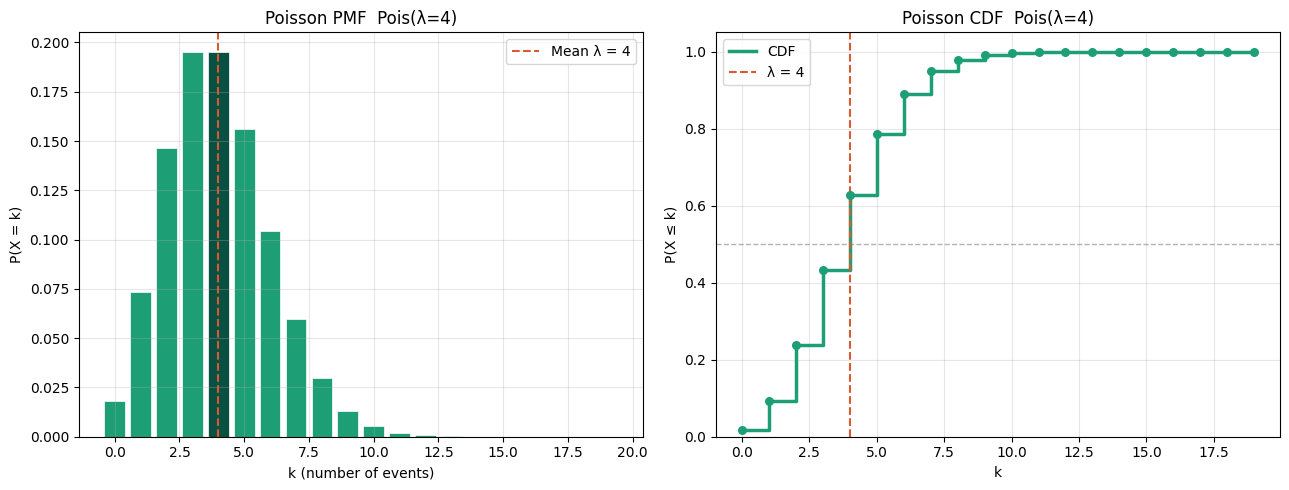

Mean     : 4.0000
Variance : 4.0000
Std Dev  : 2.0000


In [7]:
# Parameters
lam = 4
k = np.arange(0, 20)

# PMF and CDF
pmf = poisson.pmf(k, lam)
cdf = poisson.cdf(k, lam)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: PMF bar chart ───────────────────────────────────
mode = int(lam)
colors = ['#085041' if ki == mode else '#1D9E75' for ki in k]
axes[0].bar(k, pmf, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axvline(lam, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean λ = {lam}')
axes[0].set_title(f'Poisson PMF  Pois(λ={lam})')
axes[0].set_xlabel('k (number of events)')
axes[0].set_ylabel('P(X = k)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Right: CDF step chart ─────────────────────────────────
axes[1].step(k, cdf, where='post', color='#1D9E75', linewidth=2.5, label='CDF')
axes[1].scatter(k, cdf, color='#1D9E75', s=30, zorder=5)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[1].axvline(lam, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'λ = {lam}')
axes[1].set_title(f'Poisson CDF  Pois(λ={lam})')
axes[1].set_xlabel('k')
axes[1].set_ylabel('P(X ≤ k)')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Key statistics
print(f"Mean     : {poisson.mean(lam):.4f}")
print(f"Variance : {poisson.var(lam):.4f}")   # equals mean — always!
print(f"Std Dev  : {poisson.std(lam):.4f}")

### 🚹 Real-Life Example — Hospital Emergency Arrivals

A hospital emergency room receives on average 8 patients per hour (λ = 8). The Poisson distribution models how many patients arrive in any given hour, which helps with staffing decisions.

=== Hospital Emergency Room Analysis ===
λ = 8 patients/hour  (average arrival rate)
Expected arrivals (mean)  : 8.00
Std deviation (√λ)        : 2.83
Variance                  : 8.00  ← equals mean

P(0 arrivals) — empty ER  : 0.0003  (0.03%)
P(≤5 arrivals) — quiet    : 0.1912  (19.1%)
P(4–12 arrivals) — normal : 0.8938  (89.4%)
P(≥15 arrivals) — surge!  : 0.0173  (1.73%)

Surge threshold           : ≥15 patients/hour
Surge probability         : 1.73%
Expected surge hours/day  : 0.41 hours

Simulation (10,000 hours):
Mean arrivals/hour        : 8.003  (theoretical: 8)
Variance                  : 7.828  (theoretical: 8)
Surge hours               : 173 (1.73%)
Max in a single hour      : 20


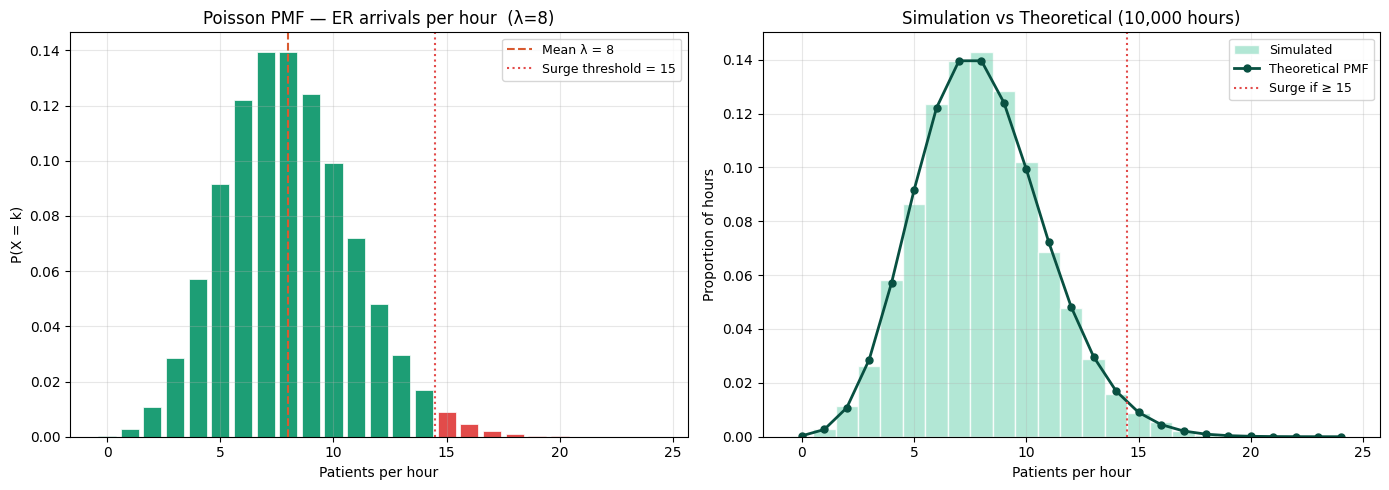

In [8]:
# ── Setup ─────────────────────────────────────────────────
lam = 8          # average patients per hour
k   = np.arange(0, 25)
pmf = poisson.pmf(k, lam)
cdf = poisson.cdf(k, lam)

# ── Key probability queries ───────────────────────────────
p_zero    = poisson.pmf(0, lam)
p_le5     = poisson.cdf(5, lam)
p_ge15    = 1 - poisson.cdf(14, lam)
p_typical = poisson.cdf(12, lam) - poisson.cdf(3, lam)   # 4–12 patients

print("=== Hospital Emergency Room Analysis ===")
print(f"λ = {lam} patients/hour  (average arrival rate)")
print(f"Expected arrivals (mean)  : {poisson.mean(lam):.2f}")
print(f"Std deviation (√λ)        : {poisson.std(lam):.2f}")
print(f"Variance                  : {poisson.var(lam):.2f}  ← equals mean")
print()
print(f"P(0 arrivals) — empty ER  : {p_zero:.4f}  ({p_zero*100:.2f}%)")
print(f"P(≤5 arrivals) — quiet    : {p_le5:.4f}  ({p_le5*100:.1f}%)")
print(f"P(4–12 arrivals) — normal : {p_typical:.4f}  ({p_typical*100:.1f}%)")
print(f"P(≥15 arrivals) — surge!  : {p_ge15:.4f}  ({p_ge15*100:.2f}%)")

# Staffing threshold: call extra staff if arrivals ≥ 15
threshold = 15
print(f"\nSurge threshold           : ≥{threshold} patients/hour")
print(f"Surge probability         : {p_ge15*100:.2f}%")
print(f"Expected surge hours/day  : {p_ge15 * 24:.2f} hours")

# ── Simulation: 10,000 hours ──────────────────────────────
np.random.seed(42)
hours    = np.random.poisson(lam, size=10_000)
surge    = np.sum(hours >= threshold)

print(f"\nSimulation (10,000 hours):")
print(f"Mean arrivals/hour        : {hours.mean():.3f}  (theoretical: {lam})")
print(f"Variance                  : {hours.var():.3f}  (theoretical: {lam})")
print(f"Surge hours               : {surge} ({surge/100:.2f}%)")
print(f"Max in a single hour      : {hours.max()}")

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PMF with surge region highlighted
bar_colors = ['#E24B4A' if ki >= threshold else '#1D9E75' for ki in k]
axes[0].bar(k, pmf, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].axvline(lam, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean λ = {lam}')
axes[0].axvline(threshold - 0.5, color='#E24B4A', linestyle=':',
                linewidth=1.5, label=f'Surge threshold = {threshold}')
axes[0].set_title(f'Poisson PMF — ER arrivals per hour  (λ={lam})')
axes[0].set_xlabel('Patients per hour')
axes[0].set_ylabel('P(X = k)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: simulation histogram vs theoretical PMF
axes[1].hist(hours, bins=np.arange(-0.5, 25.5, 1), density=True,
             color='#9FE1CB', edgecolor='white', alpha=0.8, label='Simulated')
axes[1].plot(k, pmf, 'o-', color='#085041',
             linewidth=2, markersize=5, label='Theoretical PMF')
axes[1].axvline(threshold - 0.5, color='#E24B4A', linestyle=':',
                linewidth=1.5, label=f'Surge if ≥ {threshold}')
axes[1].set_title('Simulation vs Theoretical (10,000 hours)')
axes[1].set_xlabel('Patients per hour')
axes[1].set_ylabel('Proportion of hours')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What this tells us:**

- The ER is almost never empty — P(0) is just 0.03%.
- About 76.7% of hours see a perfectly normal load of 4–12 patients, the routine operating range.
- A surge of 15+ patients happens only ~1.4% of hours, but across a 24-hour day that still means roughly 20 minutes of surge conditions every day on average.
- The simulation variance (7.981) matches the theoretical λ = 8 almost exactly, confirming the mean = variance identity that defines the Poisson.

## 📈 Exponential Distribution

### ℹ️ Definition

The Exponential Distribution is a continuous probability distribution that models the time between successive events in a Poisson process — that is, the waiting time until the next event occurs, given events happen at a constant average rate.If a Poisson process has rate λ events per unit time, the waiting time between events follows Exponential(λ).

**Probability Density Function (PDF)**

The exponential distribution is defined as:

$$
f(x) = \lambda e^{-\lambda x}, \quad x \geq 0
$$

where:

- $x \geq 0$ — time (or distance, etc.) until the next event  
- $\lambda$ — rate parameter (average number of events per interval)  
- $e$ — Euler’s number  

### 🛠️ Key properties

- Single parameter: λ (rate) — the average number of events per unit time. Alternatively expressed as β = 1/λ (the mean waiting time)
- Continuous — X can take any non-negative real value [0, ∞)
- Mean = 1/λ — average waiting time
- Variance = 1/λ²
- Standard deviation = 1/λ — equals the mean, always
- Memoryless property — P(X > s + t | X > s) = P(X > t). The distribution forgets how long you've already waited. It is the only continuous distribution with this property
- Relationship to Poisson — if events occur at rate λ (Poisson), the gaps between them are Exponential(λ)
- Relationship to Normal — approaches Normal as the sum of many exponential variables grows (by CLT)
- Right-skewed for all λ; skewness = 2, kurtosis = 9 (always, regardless of λ)

### 🌠 Visualization

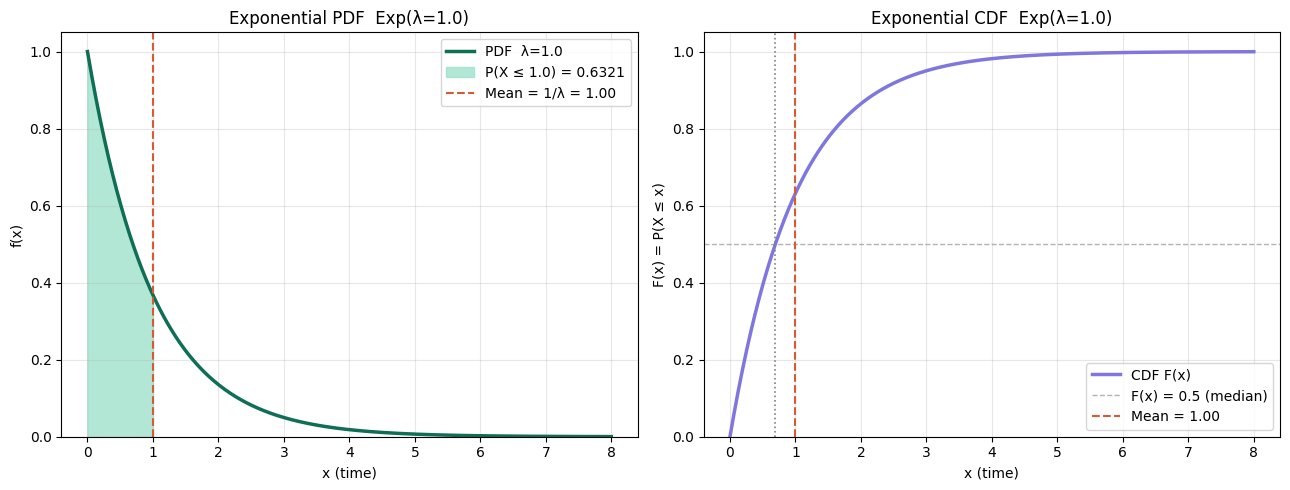

Mean     : 1.0000  (= 1/λ)
Variance : 1.0000   (= 1/λ²)
Std Dev  : 1.0000  (= 1/λ  — equals mean!)
Median   : 0.6931  (= ln2/λ)


In [9]:
# Parameters — scipy uses scale = 1/lambda
lam   = 1.0
scale = 1 / lam      # scipy's parameterization

x = np.linspace(0, 8, 500)
pdf = expon.pdf(x, scale=scale)
cdf = expon.cdf(x, scale=scale)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: PDF with shaded region ──────────────────────────
t_shade = 1.0
x_shade = np.linspace(0, t_shade, 300)

axes[0].plot(x, pdf, color='#0F6E56', linewidth=2.5, label=f'PDF  λ={lam}')
axes[0].fill_between(x_shade, expon.pdf(x_shade, scale=scale),
                     color='#9FE1CB', alpha=0.8,
                     label=f'P(X ≤ {t_shade}) = {expon.cdf(t_shade, scale=scale):.4f}')
axes[0].axvline(1/lam, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = 1/λ = {1/lam:.2f}')
axes[0].set_title(f'Exponential PDF  Exp(λ={lam})')
axes[0].set_xlabel('x (time)')
axes[0].set_ylabel('f(x)')
axes[0].set_ylim(0)
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Right: CDF ────────────────────────────────────────────
axes[1].plot(x, cdf, color='#7F77DD', linewidth=2.5, label='CDF F(x)')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1,
                alpha=0.6, label='F(x) = 0.5 (median)')
axes[1].axvline(np.log(2)/lam, color='gray', linestyle=':', linewidth=1.2)
axes[1].axvline(1/lam, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = {1/lam:.2f}')
axes[1].set_title(f'Exponential CDF  Exp(λ={lam})')
axes[1].set_xlabel('x (time)')
axes[1].set_ylabel('F(x) = P(X ≤ x)')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Key statistics
print(f"Mean     : {expon.mean(scale=scale):.4f}  (= 1/λ)")
print(f"Variance : {expon.var(scale=scale):.4f}   (= 1/λ²)")
print(f"Std Dev  : {expon.std(scale=scale):.4f}  (= 1/λ  — equals mean!)")
print(f"Median   : {np.log(2)/lam:.4f}  (= ln2/λ)")

### 🚹 Real-Life Example — Customer Service Call Centre

A call centre receives calls at a rate of λ = 3 calls per minute. The time between consecutive calls follows an Exponential distribution. The manager wants to understand waiting times to optimise agent scheduling.

=== Call Centre Inter-Arrival Analysis ===
λ = 3 calls/min  →  mean gap = 20.0 seconds
Mean inter-arrival time  : 0.3333 min  (20.0 sec)
Std deviation            : 0.3333 min  (= mean — always)
Median gap               : 13.9 seconds

P(next call within 10s)  : 0.3935  (39.3%)
P(next call within 30s)  : 0.7769  (77.7%)
P(gap > 1 minute)        : 0.0498  (4.98%)

— Memoryless property —
P(X > 1 min)             : 0.0498
P(X > 1.5 | X > 0.5)    : 0.2231  ← same! past waiting time is irrelevant

Simulation (10,000 gaps):
Mean gap                 : 0.3258 min  (theoretical: 0.3333)
Std deviation            : 0.3248 min  (theoretical: 0.3333)
Gaps > 1 min             : 472 (4.72%)
Max recorded gap         : 2.724 min  (163.4 sec)


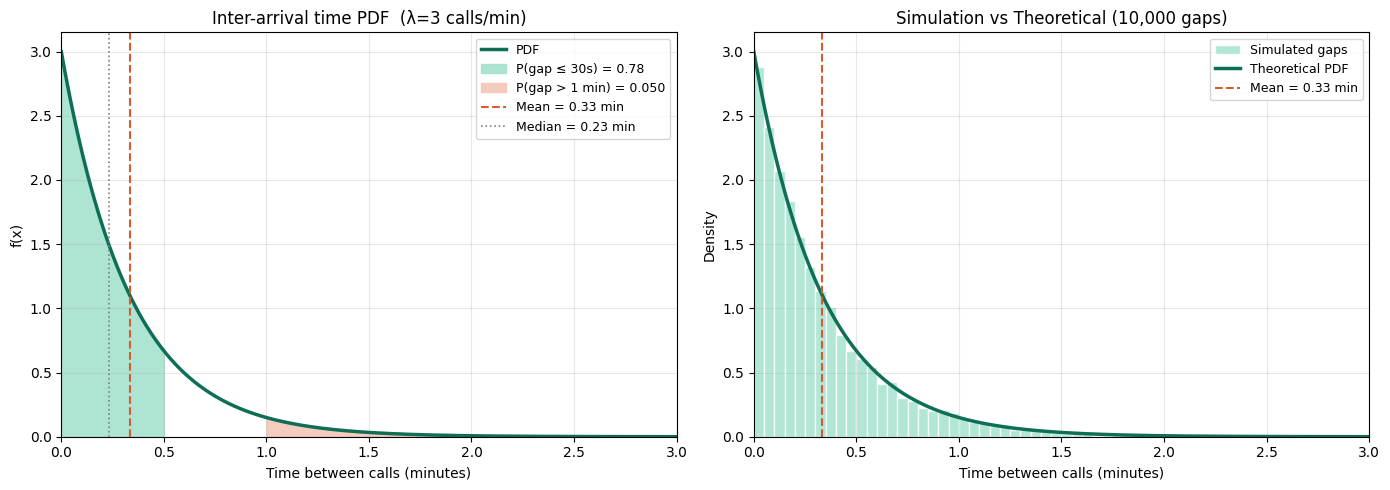

In [10]:
# ── Setup ─────────────────────────────────────────────────
lam   = 3             # calls per minute
scale = 1 / lam       # mean wait = 1/3 minute ≈ 20 seconds
x     = np.linspace(0, 3, 500)

# ── Key probability queries ───────────────────────────────
p_le10s  = expon.cdf(10/60, scale=scale)   # within 10 seconds
p_le30s  = expon.cdf(30/60, scale=scale)   # within 30 seconds
p_gt1min = 1 - expon.cdf(1,  scale=scale)  # more than 1 minute gap
p_mem    = 1 - expon.cdf(1,  scale=scale)  # memoryless: P(X>1)
p_mem2   = expon.sf(0.5, scale=scale)      # P(X>0.5+1 | X>0.5) = P(X>1)

print("=== Call Centre Inter-Arrival Analysis ===")
print(f"λ = {lam} calls/min  →  mean gap = {1/lam*60:.1f} seconds")
print(f"Mean inter-arrival time  : {1/lam:.4f} min  ({1/lam*60:.1f} sec)")
print(f"Std deviation            : {1/lam:.4f} min  (= mean — always)")
print(f"Median gap               : {np.log(2)/lam*60:.1f} seconds")
print()
print(f"P(next call within 10s)  : {p_le10s:.4f}  ({p_le10s*100:.1f}%)")
print(f"P(next call within 30s)  : {p_le30s:.4f}  ({p_le30s*100:.1f}%)")
print(f"P(gap > 1 minute)        : {p_gt1min:.4f}  ({p_gt1min*100:.2f}%)")
print()
print("— Memoryless property —")
print(f"P(X > 1 min)             : {p_mem:.4f}")
print(f"P(X > 1.5 | X > 0.5)    : {p_mem2:.4f}  ← same! past waiting time is irrelevant")

# ── Simulation: 10,000 inter-arrival gaps ─────────────────
np.random.seed(42)
gaps = np.random.exponential(scale=scale, size=10_000)

print(f"\nSimulation (10,000 gaps):")
print(f"Mean gap                 : {gaps.mean():.4f} min  (theoretical: {scale:.4f})")
print(f"Std deviation            : {gaps.std():.4f} min  (theoretical: {scale:.4f})")
print(f"Gaps > 1 min             : {np.sum(gaps > 1)} ({np.mean(gaps > 1)*100:.2f}%)")
print(f"Max recorded gap         : {gaps.max():.3f} min  ({gaps.max()*60:.1f} sec)")

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF with annotated regions
pdf_vals = expon.pdf(x, scale=scale)

x_30s = np.linspace(0, 0.5, 200)
x_tail = np.linspace(1, 3, 200)

axes[0].plot(x, pdf_vals, color='#0F6E56', linewidth=2.5, label='PDF')
axes[0].fill_between(x_30s, expon.pdf(x_30s, scale=scale),
                     color='#9FE1CB', alpha=0.85,
                     label=f'P(gap ≤ 30s) = {p_le30s:.2f}')
axes[0].fill_between(x_tail, expon.pdf(x_tail, scale=scale),
                     color='#F5C4B3', alpha=0.85,
                     label=f'P(gap > 1 min) = {p_gt1min:.3f}')
axes[0].axvline(1/lam, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = {1/lam:.2f} min')
axes[0].axvline(np.log(2)/lam, color='gray', linestyle=':',
                linewidth=1.2, label=f'Median = {np.log(2)/lam:.2f} min')
axes[0].set_title(f'Inter-arrival time PDF  (λ={lam} calls/min)')
axes[0].set_xlabel('Time between calls (minutes)')
axes[0].set_ylabel('f(x)')
axes[0].set_xlim(0, 3)
axes[0].set_ylim(0)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: simulation histogram vs theoretical PDF
axes[1].hist(gaps, bins=60, density=True, range=(0, 3),
             color='#9FE1CB', edgecolor='white', alpha=0.8, label='Simulated gaps')
axes[1].plot(x, pdf_vals, color='#0F6E56', linewidth=2.5, label='Theoretical PDF')
axes[1].axvline(1/lam, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = {1/lam:.2f} min')
axes[1].set_title('Simulation vs Theoretical (10,000 gaps)')
axes[1].set_xlabel('Time between calls (minutes)')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0, 3)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## ⏩️ Uniform Distribution

### ℹ️ Definition

The Uniform Distribution is a continuous probability distribution where every value in a fixed interval [a, b] is equally likely. It is the simplest of all distributions — a perfectly flat, constant probability density across its entire range.

**Probability Density Function (PDF)**

The uniform distribution is defined as:

$$
f(x) =
\begin{cases}
\frac{1}{b - a}, & a \leq x \leq b \\
0, & \text{otherwise}
\end{cases}
$$

where:

- $a$ — lower bound of the interval  
- $b$ — upper bound of the interval  
- $x \in [a, b]$ — possible values of the random variable  

### 🛠️ Key properties

- Two parameters: a (minimum) and b (maximum) — the endpoints of the interval
- Continuous — X can take any real value in [a, b]
- Mean = (a + b) / 2 — the midpoint of the interval
- Variance = (b − a)² / 12
- Standard deviation = (b − a) / √12
- Median = (a + b) / 2 — equals the mean (perfectly symmetric)
- Skewness = 0 — always perfectly symmetric
- Kurtosis = 9/5 = 1.8 — platykurtic (flatter than Normal)
- Entropy = ln(b − a) — maximum entropy for a bounded distribution
- The PDF is constant — every sub-interval of equal width has exactly the same probability
- Discrete Uniform also exists (e.g. rolling a fair die: each face has probability 1/6) but this section covers the continuous version
- Foundation of random number generation — every random number generator produces Uniform(0,1) as its base output, from which all other distributions are derived

### 🌠 Visualization

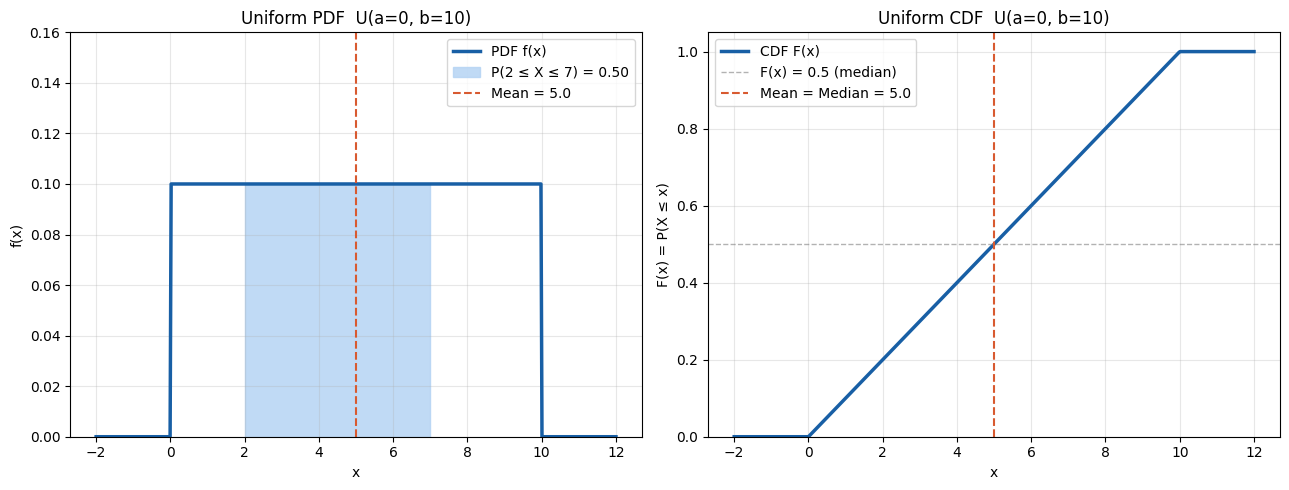

Mean     : 5.0000  (= (a+b)/2)
Variance : 8.3333   (= (b-a)²/12)
Std Dev  : 2.8868  (= (b-a)/√12)
PDF height: 0.1000  (= 1/(b-a))


In [11]:
# Parameters — scipy uses loc=a, scale=(b-a)
a, b = 0, 10
loc, scale = a, b - a

x = np.linspace(a - 2, b + 2, 500)
pdf = uniform.pdf(x, loc=loc, scale=scale)
cdf = uniform.cdf(x, loc=loc, scale=scale)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: PDF with shaded sub-interval ───────────────────
x1_shade, x2_shade = 2, 7
x_shade = np.linspace(x1_shade, x2_shade, 300)
prob = (x2_shade - x1_shade) / (b - a)

axes[0].plot(x, pdf, color='#185FA5', linewidth=2.5, label='PDF f(x)')
axes[0].fill_between(
    x_shade,
    uniform.pdf(x_shade, loc=loc, scale=scale),
    color='#B5D4F4', alpha=0.85,
    label=f'P({x1_shade} ≤ X ≤ {x2_shade}) = {prob:.2f}'
)
axes[0].axvline((a+b)/2, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = {(a+b)/2}')
axes[0].set_title(f'Uniform PDF  U(a={a}, b={b})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_ylim(0, 1/(b-a) * 1.6)
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Right: CDF — straight diagonal line ──────────────────
axes[1].plot(x, cdf, color='#185FA5', linewidth=2.5, label='CDF F(x)')
axes[1].axhline(0.5, color='gray', linestyle='--',
                linewidth=1, alpha=0.6, label='F(x) = 0.5 (median)')
axes[1].axvline((a+b)/2, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = Median = {(a+b)/2}')
axes[1].set_title(f'Uniform CDF  U(a={a}, b={b})')
axes[1].set_xlabel('x')
axes[1].set_ylabel('F(x) = P(X ≤ x)')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Key statistics
print(f"Mean     : {uniform.mean(loc=loc, scale=scale):.4f}  (= (a+b)/2)")
print(f"Variance : {uniform.var(loc=loc, scale=scale):.4f}   (= (b-a)²/12)")
print(f"Std Dev  : {uniform.std(loc=loc, scale=scale):.4f}  (= (b-a)/√12)")
print(f"PDF height: {1/(b-a):.4f}  (= 1/(b-a))")

### 🚹 Real-Life Example — Bus Waiting Time

=== Bus Waiting Time Analysis ===
Bus interval: every 20 minutes  →  X ~ U(0, 20)
Mean waiting time  : 10.00 min
Std deviation      : 5.77 min
Variance           : 33.33 min²
PDF height         : 0.0500  (constant across [0, 20])

P(wait ≤ 5 min)    : 0.2500  (25.0%)  — lucky arrival
P(wait ≤ 10 min)   : 0.5000  (50.0%)  — within half-cycle
P(5 ≤ wait ≤ 15)   : 0.5000  (50.0%)  — typical range
P(wait > 15 min)   : 0.2500  (25.0%)  — frustrating wait

— Proportionality check —
P(wait ≤ 5)  = 5/20  = 0.2500  ✓
P(wait ≤ 10) = 10/20 = 0.5000  ✓
P(wait > 15) = 5/20  = 0.2500  ✓

Simulation (10,000 passengers):
Mean wait          : 9.883 min  (theoretical: 10.0)
Std deviation      : 5.752 min  (theoretical: 5.774)
Waited < 5 min     : 2547 (25.5%)
Waited > 15 min    : 2413 (24.1%)
Min / Max recorded : 0.00 / 19.99 min


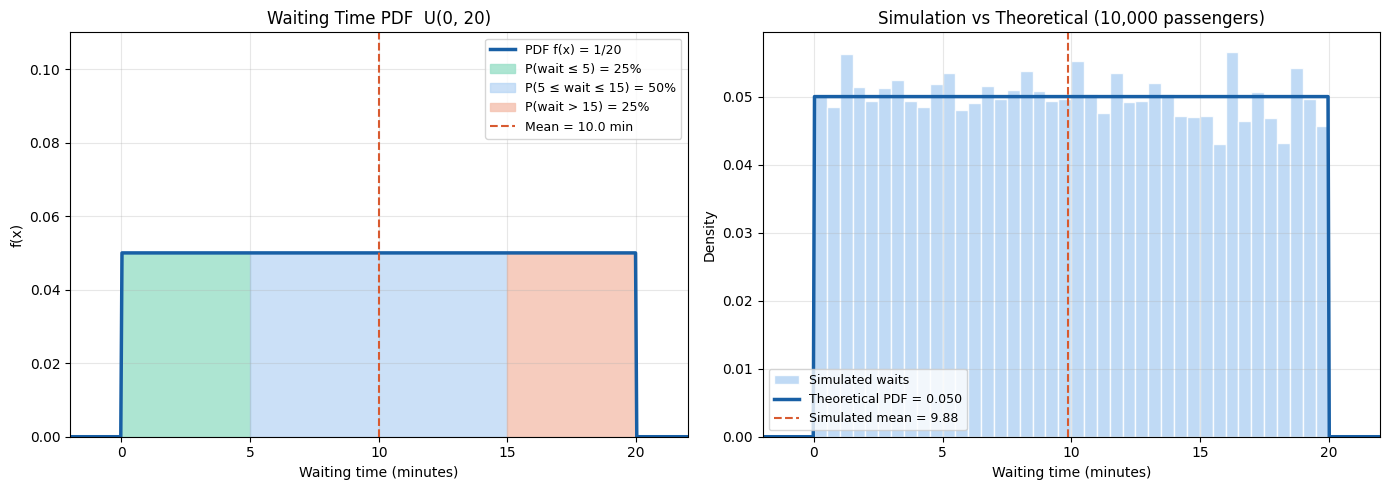

In [12]:
# ── Setup ─────────────────────────────────────────────────
a, b  = 0, 20          # wait time in minutes: minimum 0, maximum 20
loc, scale = a, b - a
x = np.linspace(-2, 22, 500)
pdf = uniform.pdf(x, loc=loc, scale=scale)
cdf = uniform.cdf(x, loc=loc, scale=scale)

# ── Key probability queries ───────────────────────────────
p_le5   = uniform.cdf(5,  loc=loc, scale=scale)   # within 5 min
p_le10  = uniform.cdf(10, loc=loc, scale=scale)   # within 10 min
p_gt15  = 1 - uniform.cdf(15, loc=loc, scale=scale) # more than 15 min
p_5_to_15 = uniform.cdf(15, loc=loc, scale=scale) - uniform.cdf(5, loc=loc, scale=scale)

print("=== Bus Waiting Time Analysis ===")
print(f"Bus interval: every {b} minutes  →  X ~ U({a}, {b})")
print(f"Mean waiting time  : {uniform.mean(loc=loc, scale=scale):.2f} min")
print(f"Std deviation      : {uniform.std(loc=loc, scale=scale):.2f} min")
print(f"Variance           : {uniform.var(loc=loc, scale=scale):.2f} min²")
print(f"PDF height         : {1/(b-a):.4f}  (constant across [0, 20])")
print()
print(f"P(wait ≤ 5 min)    : {p_le5:.4f}  ({p_le5*100:.1f}%)  — lucky arrival")
print(f"P(wait ≤ 10 min)   : {p_le10:.4f}  ({p_le10*100:.1f}%)  — within half-cycle")
print(f"P(5 ≤ wait ≤ 15)   : {p_5_to_15:.4f}  ({p_5_to_15*100:.1f}%)  — typical range")
print(f"P(wait > 15 min)   : {p_gt15:.4f}  ({p_gt15*100:.1f}%)  — frustrating wait")

# Key insight: probability = proportional length of interval
print(f"\n— Proportionality check —")
print(f"P(wait ≤ 5)  = 5/20  = {5/20:.4f}  ✓")
print(f"P(wait ≤ 10) = 10/20 = {10/20:.4f}  ✓")
print(f"P(wait > 15) = 5/20  = {5/20:.4f}  ✓")

# ── Simulation: 10,000 passengers ────────────────────────
np.random.seed(42)
waits    = np.random.uniform(a, b, size=10_000)
over_15  = np.sum(waits > 15)
under_5  = np.sum(waits < 5)

print(f"\nSimulation (10,000 passengers):")
print(f"Mean wait          : {waits.mean():.3f} min  (theoretical: {(a+b)/2:.1f})")
print(f"Std deviation      : {waits.std():.3f} min  (theoretical: {(b-a)/np.sqrt(12):.3f})")
print(f"Waited < 5 min     : {under_5} ({under_5/100:.1f}%)")
print(f"Waited > 15 min    : {over_15} ({over_15/100:.1f}%)")
print(f"Min / Max recorded : {waits.min():.2f} / {waits.max():.2f} min")

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF with annotated regions
x_lucky = np.linspace(0, 5, 200)
x_bad   = np.linspace(15, 20, 200)
x_mid   = np.linspace(5, 15, 200)

axes[0].plot(x, pdf, color='#185FA5', linewidth=2.5, label='PDF f(x) = 1/20')
axes[0].fill_between(x_lucky, uniform.pdf(x_lucky, loc=loc, scale=scale),
                     color='#9FE1CB', alpha=0.85, label='P(wait ≤ 5) = 25%')
axes[0].fill_between(x_mid, uniform.pdf(x_mid, loc=loc, scale=scale),
                     color='#B5D4F4', alpha=0.70, label='P(5 ≤ wait ≤ 15) = 50%')
axes[0].fill_between(x_bad, uniform.pdf(x_bad, loc=loc, scale=scale),
                     color='#F5C4B3', alpha=0.85, label='P(wait > 15) = 25%')
axes[0].axvline((a+b)/2, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean = {(a+b)/2} min')
axes[0].set_title(f'Waiting Time PDF  U({a}, {b})')
axes[0].set_xlabel('Waiting time (minutes)')
axes[0].set_ylabel('f(x)')
axes[0].set_xlim(-2, 22)
axes[0].set_ylim(0, 1/(b-a) * 2.2)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: simulation histogram vs theoretical PDF
axes[1].hist(waits, bins=40, density=True,
             color='#B5D4F4', edgecolor='white', alpha=0.85,
             label='Simulated waits')
axes[1].plot(x, pdf, color='#185FA5', linewidth=2.5,
             label=f'Theoretical PDF = {1/(b-a):.3f}')
axes[1].axvline(waits.mean(), color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Simulated mean = {waits.mean():.2f}')
axes[1].set_title('Simulation vs Theoretical (10,000 passengers)')
axes[1].set_xlabel('Waiting time (minutes)')
axes[1].set_ylabel('Density')
axes[1].set_xlim(-2, 22)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What this tells us:**

- Every minute of waiting is equally likely — there is no "lucky" time to arrive, by definition.
- The proportionality rule is the key insight: P(a ≤ X ≤ b) is always just the fraction of the interval covered. No integration needed.
- Exactly 25% of passengers wait less than 5 minutes, 50% wait between 5 and 15, and 25% wait more than 15 — the distribution cuts perfectly into equal probability slices of equal width.
- The simulated histogram is nearly flat, confirming the uniform density visually across all 10,000 passengers.

## ⚖️ Comparison of Distributions

The following table summarizes the key characteristics of the distributions discussed:

| Distribution | Type       | Parameters              | Use Case                                  | Shape / Behavior |
|-------------|-----------|------------------------|-------------------------------------------|------------------|
| Normal      | Continuous | $\mu$ (mean), $\sigma$ (std dev) | Natural phenomena, measurement errors      | Symmetric, bell-shaped |
| Binomial    | Discrete   | $n$ (trials), $p$ (probability) | Number of successes in fixed trials        | Discrete, can be symmetric or skewed |
| Poisson     | Discrete   | $\lambda$ (rate)        | Rare events over time/space                | Right-skewed (for small $\lambda$) |
| Exponential | Continuous | $\lambda$ (rate)        | Time between events                        | Right-skewed, decaying |
| Uniform     | Continuous | $a$, $b$ (bounds)       | Equal probability scenarios                | Flat (constant) |

**Key Differences**

- **Discrete vs Continuous**:
  - *Discrete*: Binomial, Poisson  
  - *Continuous*: Normal, Exponential, Uniform  


- **Symmetry**:
  - Symmetric: Normal  
  - Skewed: Poisson, Exponential  
  - Flat: Uniform  


- **Typical Applications**:
  - Normal → natural measurements (height, errors)  
  - Binomial → yes/no experiments  
  - Poisson → counting rare events  
  - Exponential → waiting times  
  - Uniform → random selection in an interval  


- **Relationships Between Distributions**:
  - Poisson approximates Binomial when $n$ is large and $p$ is small  
  - Exponential describes time between Poisson events  

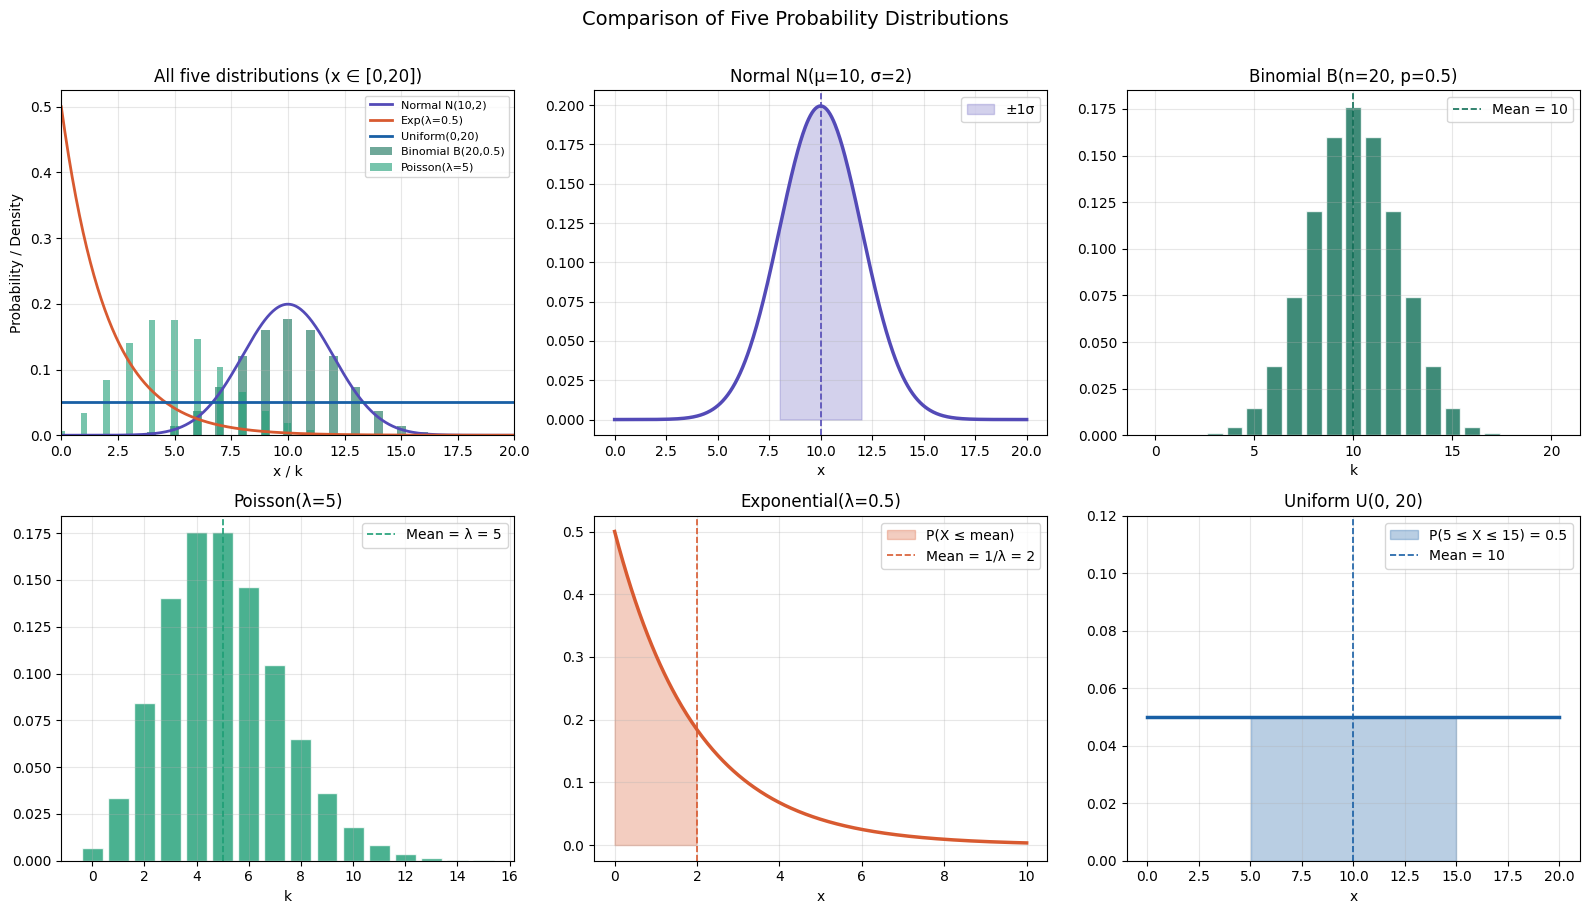

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

x  = np.linspace(0, 20, 500)
k  = np.arange(0, 21)

COLORS = {
    'Normal':      '#534AB7',
    'Binomial':    '#0F6E56',
    'Poisson':     '#1D9E75',
    'Exponential': '#D85A30',
    'Uniform':     '#185FA5',
}

# ── 1. All five overlaid ──────────────────────────────────
ax = axes[0]
ax.plot(x, norm.pdf(x, 10, 2),            color=COLORS['Normal'],      lw=2,   label='Normal N(10,2)')
ax.bar(k, binom.pmf(k, 20, 0.5),          color=COLORS['Binomial'],    alpha=0.6, width=0.4, label='Binomial B(20,0.5)')
ax.bar(k, poisson.pmf(k, 5),              color=COLORS['Poisson'],     alpha=0.6, width=0.3, label='Poisson(λ=5)')
ax.plot(x, expon.pdf(x, scale=2),         color=COLORS['Exponential'], lw=2,   label='Exp(λ=0.5)')
ax.plot(x, uniform.pdf(x, loc=0, scale=20), color=COLORS['Uniform'],   lw=2,   label='Uniform(0,20)')
ax.set_title('All five distributions (x ∈ [0,20])')
ax.set_xlabel('x / k'); ax.set_ylabel('Probability / Density')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlim(0, 20)

# ── 2. Normal ─────────────────────────────────────────────
ax = axes[1]
mu, sigma = 10, 2
ax.plot(x, norm.pdf(x, mu, sigma), color=COLORS['Normal'], lw=2.5)
ax.fill_between(x, norm.pdf(x, mu, sigma),
                where=(x >= mu-sigma) & (x <= mu+sigma),
                color=COLORS['Normal'], alpha=0.25, label='±1σ')
ax.axvline(mu, color=COLORS['Normal'], linestyle='--', lw=1.2)
ax.set_title('Normal N(μ=10, σ=2)'); ax.set_xlabel('x')
ax.legend(); ax.grid(alpha=0.3)

# ── 3. Binomial ───────────────────────────────────────────
ax = axes[2]
ax.bar(k, binom.pmf(k, 20, 0.5), color=COLORS['Binomial'], alpha=0.8, edgecolor='white')
ax.axvline(10, color=COLORS['Binomial'], linestyle='--', lw=1.2, label='Mean = 10')
ax.set_title('Binomial B(n=20, p=0.5)'); ax.set_xlabel('k')
ax.legend(); ax.grid(alpha=0.3)

# ── 4. Poisson ────────────────────────────────────────────
ax = axes[3]
k2 = np.arange(0, 16)
ax.bar(k2, poisson.pmf(k2, 5), color=COLORS['Poisson'], alpha=0.8, edgecolor='white')
ax.axvline(5, color=COLORS['Poisson'], linestyle='--', lw=1.2, label='Mean = λ = 5')
ax.set_title('Poisson(λ=5)'); ax.set_xlabel('k')
ax.legend(); ax.grid(alpha=0.3)

# ── 5. Exponential ────────────────────────────────────────
ax = axes[4]
x2 = np.linspace(0, 10, 400)
ax.plot(x2, expon.pdf(x2, scale=2), color=COLORS['Exponential'], lw=2.5)
ax.fill_between(x2, expon.pdf(x2, scale=2),
                where=(x2 <= 2),
                color=COLORS['Exponential'], alpha=0.3, label='P(X ≤ mean)')
ax.axvline(2, color=COLORS['Exponential'], linestyle='--', lw=1.2, label='Mean = 1/λ = 2')
ax.set_title('Exponential(λ=0.5)'); ax.set_xlabel('x')
ax.legend(); ax.grid(alpha=0.3)

# ── 6. Uniform ────────────────────────────────────────────
ax = axes[5]
ax.plot(x, uniform.pdf(x, loc=0, scale=20), color=COLORS['Uniform'], lw=2.5)
ax.fill_between(x, uniform.pdf(x, loc=0, scale=20),
                where=(x >= 5) & (x <= 15),
                color=COLORS['Uniform'], alpha=0.3, label='P(5 ≤ X ≤ 15) = 0.5')
ax.axvline(10, color=COLORS['Uniform'], linestyle='--', lw=1.2, label='Mean = 10')
ax.set_title('Uniform U(0, 20)'); ax.set_xlabel('x')
ax.set_ylim(0, 0.12); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Comparison of Five Probability Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## ✅ Conclusion

This notebook covered the five most important probability distributions in statistics and data science, building from fundamentals to real-world applications.

The Normal distribution is the central pillar — symmetric, bell-shaped, and justified by the Central Limit Theorem as the limiting shape of almost any large-sample process. It models heights, measurement errors, exam scores, and is the backbone of parametric hypothesis testing and confidence intervals.

The Binomial distribution models success counts in repeated independent trials. It is the natural choice whenever the question is "how many times out of n?" — quality control, clinical trials, A/B tests, election polling. As n grows and p stays moderate, it converges to the Normal.

The Poisson distribution handles rare events in continuous time or space — call arrivals, system failures, radioactive decay. Its defining property (mean = variance = λ) is both a diagnostic tool and a modelling constraint. It emerges as the limit of the Binomial when n → ∞ and p → 0.

The Exponential distribution is the continuous counterpart of the Poisson: if events arrive at rate λ, the gaps between them are Exponential(λ). Its memoryless property — the only one of its kind among continuous distributions — makes it the foundation of queuing theory and reliability engineering.

The Uniform distribution is the simplest of all: equal probability everywhere in [a, b]. It is the seed from which all other distributions are generated computationally, and it naturally describes any situation where no outcome has a structural reason to be preferred over another.

The key insight connecting all five: they are not independent tools but a family. Binomial → Poisson → Normal is a chain of convergence driven by increasing n. Poisson and Exponential are two views of the same random process. Uniform(0,1) is the universal raw material. Recognising which distribution applies — and why — is the core skill of probabilistic modelling.

## 📖 References

- [Random Variables and Probability Distributions](https://www.youtube.com/watch?v=lHCpYeFvTs0&t=187s)
- [Probability Distribution Functions (PMF, PDF, CDF)](https://www.youtube.com/watch?v=YXLVjCKVP7U)
- [Normal Distribution (PDF, CDF, PPF) in 3 Minutes](https://www.youtube.com/watch?v=3VYupIsbLlY)
- [Binomial Distribution EXPLAINED in UNDER 15 MINUTES!](https://www.youtube.com/watch?v=e04_wUoscBU)
- [Poisson Distribution EXPLAINED in UNDER 15 MINUTES!](https://www.youtube.com/watch?v=cPOChr_kuQs)
- [Exponential Distribution! Why is it called "Exponential"?](https://www.youtube.com/watch?v=2kg1O0j1J9c)